<a href="https://colab.research.google.com/github/yin-penghang/AMAT593/blob/main/16_Deep_Neural_Networks/01_Deep_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Neural Networks

The code for network training should be executed within Google's [Colab Notebook](https://colab.research.google.com/github/yin-penghang/AMAT593/blob/main/16_Deep-Neural-Networks/01_Deep%20Neural%20Networks.ipynb) using GPU.

## Basics

In deep learning, we take deep neural networks as the model architecture. The word "deep" in "deep learning" refers to the number of layers through which the data is transformed. Deep learning architectures such as convolutional neural networks, recurrent neural networks and transformers have been applied to fields including computer vision, speech recognition, sentiment analysis, machine translation, bioinformatics, drug design, medical image analysis, material inspection and board game programs, where they have produced results comparable to and in some cases surpassing human expert performance.

### Why GPU For Deep Learning

A CPU in general completes its task in a **sequential** manner, whereas a GPU is the able to process a large number of simple calculations **in parallel**, which makes it very suitable for computing matrix multiplications and convolutions in deep learning.

### Deep Learning Libraries and Platforms

There are a number of open-source deep learning libraries and platforms available. Among them, [PyTorch](https://pytorch.org/) by Facebook and [TensorFlow](https://www.tensorflow.org/) by Google are the most popular for academic and research activities.

We will use TensorFlow for lecturing. We will also need **Keras**, which is a high-level neural network library that runs on top of TensorFlow.

You need to install Python dependecies ``tensorflow`` and ``keras`` for deep learning:
- ``pip install tensorflow``
- ``pip install keras``

Building neural network models is like playing Lego, deep learning libraries provide the modules of different types of layers — Lego blocks  — to construct network architectures in a flexible way. They also include various convenient utility functions such as metrics as well as optimizers, making deep learning easy to train and deploy.

## Enabling GPU in Colab Notebook

GPUs can process data several orders of magnitude faster than a CPU due to **massive parallelism**, although GPUs are not as versatile as CPUs.

However, setting up a GPU so that it is ready for deep learning can be painful, as it requires the installation of several open-source softwares whose respective versions need to be compatible. **We can skip the software requirement if using GPU-enbaled Colab Notebook.**

First, you'll need to enable GPU for the notebook:

- Navigate to Edit→Notebook Settings
- select GPU from the Hardware Accelerator drop-down

Next, we'll confirm that we can connect to the GPU with tensorflow:

In [2]:
import tensorflow as tf
import timeit

In [3]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


### Observe TensorFlow speedup on GPU relative to CPU

This example constructs a typical convolutional layer over a
random image and manually places the resulting ops on either the CPU or the GPU to compare execution speed.

In [4]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print(
      '\n\nThis error most likely means that this notebook is not '
      'configured to use a GPU.  Change this in Notebook Settings via the '
      'command palette (cmd/ctrl-shift-P) or the Edit menu.\n\n')
  raise SystemError('GPU device not found')

def cpu():
  with tf.device('/cpu:0'):
    random_image_cpu = tf.random.normal((100, 100, 100, 3))
    net_cpu = tf.keras.layers.Conv2D(32, 7)(random_image_cpu)
    return tf.math.reduce_sum(net_cpu)

def gpu():
  with tf.device('/device:GPU:0'):
    random_image_gpu = tf.random.normal((100, 100, 100, 3))
    net_gpu = tf.keras.layers.Conv2D(32, 7)(random_image_gpu)
    return tf.math.reduce_sum(net_gpu)

# We run each op once to warm up
cpu()
gpu()

# Run the op several times.
print('Time (s) to convolve 32x7x7x3 filter over random 100x100x100x3 images '
      '(batch size x height x width x channel).')
print('\n CPU time (s):')
cpu_time = timeit.timeit('cpu()', number=10, setup="from __main__ import cpu")
print(cpu_time)
print('\n GPU time (s):')
gpu_time = timeit.timeit('gpu()', number=10, setup="from __main__ import gpu")
print(gpu_time)
print('\n GPU speedup over CPU: {}x'.format(int(cpu_time/gpu_time)))

Time (s) to convolve 32x7x7x3 filter over random 100x100x100x3 images (batch size x height x width x channel).

 CPU time (s):
5.728310348999912

 GPU time (s):
0.11285119800004395

 GPU speedup over CPU: 50x


## Deep Learning with Local GPU

There are limitations of using Colab's GPU for deep learning. For example, the GPU allocation per non-paid user is restricted to maximum 12 hours at a time. The next time you can use it will probably be after 12 hours or once another user has given up GPU ability.

If you have a bare machine with an **NVIDIA** GPU card available, you may want to set up your own computers to be deep learning ready. The main reason that you need an NVIDIA GPU is because of [CUDA](https://en.wikipedia.org/wiki/CUDA). CUDA is a proprietary programming framework developed by NVIDIA that facilitates massive parallelization of computing tasks using the cores in an NVIDIA GPU. You'll also need to install [cuDNN](https://developer.nvidia.com/cudnn), a GPU-accelerated library of primitives for deep neural networks built using CUDA.

Please check out [this article](https://spltech.co.uk/building-my-first-pc-for-deep-learning/) for details.

## MNIST Data preparation

Load MNIST dataset from Keras and Preprocess

In [7]:
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

load (download if needed) the MNIST dataset

In [8]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
print(X_train.shape), print(y_train.shape)

(60000, 28, 28)
(60000,)


(None, None)

In [10]:
print(X_test.shape), print(y_test.shape)

(10000, 28, 28)
(10000,)


(None, None)

Plot 4 images as gray scale

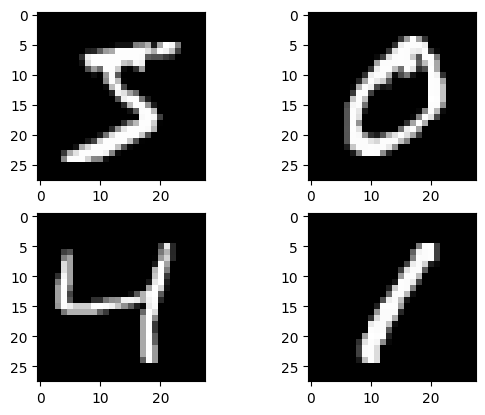

In [11]:
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(X_train[i], cmap=plt.get_cmap('gray'))

## Warmup Example 1 : Logistic Regression

To use logistic regression model, we will need to first flatten out the image samples into vectors.

<img src='https://github.com/yin-penghang/AMAT593/blob/main/figs/16_MNIST_LR.png?raw=1' width = '800'>

Flatten 28x28 images to a 784 vector for each image

In [12]:
num_pixels = X_train.shape[1] * X_train.shape[2]
X_train = X_train.reshape((X_train.shape[0], num_pixels)).astype('float32')
X_test = X_test.reshape((X_test.shape[0], num_pixels)).astype('float32')

Normalize inputs from 0-255 to 0-1

In [13]:
X_tr = X_train / 255
X_te = X_test / 255

Encode one-hot labels which are 10-D vectors, e.g.,
- digit 0 -> label (1,0,0,...,0)
- digit 1 -> label (0,1,0,...,0)
- digit 2 -> label (0,0,1,...,0)
- ...
- digit 9 -> label (0,0,0,...,1)

In [14]:
y_tr = to_categorical(y_train,10)
y_te = to_categorical(y_test,10)
num_classes = y_te.shape[1]

print(y_tr.shape)

(60000, 10)


### Implementation

Create a new instance of a model object using the Keras **`Sequential` API**.
The core idea of `Sequential` API is simply arranging the Keras layers in a sequential order. Most of the neural networks has layers in sequential order and the data flows from one layer to another layer in the given order until the data finally reaches the output layer.

Specifically, we add a dense layer (fully-connected layer), followed by softmax function that normalizes outputs into probabilities which sum to one. We use ``categorical_crossentropy`` cross-entropy loss and ``adam`` optimization algorithm.

Another popular way to create models in Keras is the **functional API** which is more flexible than `Sequential` API. The functional API can handle models with non-linear topology, shared layers, and multiple inputs or outputs.


[Adam](https://arxiv.org/pdf/1412.6980.pdf) is a SGD variant with adaptive learning rate for each individual parameter. It is an viable alternative to Nesterov accelerated SGD and has gained much popularity in deep learning, because it requires only **minimum tuning of learning rate and other algorithmic hyper-parameters**.

In [15]:
from keras.models import Sequential
from keras.layers import Dense

Use `Sequential` API:

In [16]:
def logit_model():
  # create model
  model = Sequential()
  # Fully-connected Layer with Softmax output
  model.add(Dense(units = num_classes, activation='softmax'))
  # Compile model with corss entropy loss and Adam optimizer
  model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
  return model

If we use the functional API, it will be like:

In [17]:
from keras.models import Model
from keras.layers import Input

In [18]:
def logit_model():
  # Input layer
  input = Input(shape = (num_pixels,))
  # Fully-connected Layer with Softmax output
  output = Dense(units = num_classes, activation='softmax')(input)

  model = Model(inputs = input, outputs = output)
  # Compile model with corss entropy loss and Adam optimizer
  model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
  return model

### Model Validation:

* `ModelCheckpoint` callback will ensure that the weights of model with the best validation accuracy is saved for the run for us to use later.  
* use `EarlyStopping` callback to interrupt training when the validation accuracy
is not improving for `patience=7` consecutive epochs.


In [19]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [20]:
path_checkpoint = "logit_checkpoint.weights.h5"
es_callback = EarlyStopping(monitor="val_accuracy", patience=7)

modelckpt_callback = ModelCheckpoint(
    monitor="val_accuracy",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

In [21]:
# build the model
model = logit_model()
# Fit the model
model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
          epochs=40, batch_size=100,
          callbacks=[es_callback, modelckpt_callback],
          verbose=2)

Epoch 1/40

Epoch 1: val_accuracy improved from None to 0.90610, saving model to logit_checkpoint.weights.h5

Epoch 1: finished saving model to logit_checkpoint.weights.h5
600/600 - 3s - 5ms/step - accuracy: 0.8412 - loss: 0.6338 - val_accuracy: 0.9061 - val_loss: 0.3646
Epoch 2/40

Epoch 2: val_accuracy improved from 0.90610 to 0.91570, saving model to logit_checkpoint.weights.h5

Epoch 2: finished saving model to logit_checkpoint.weights.h5
600/600 - 2s - 3ms/step - accuracy: 0.9057 - loss: 0.3475 - val_accuracy: 0.9157 - val_loss: 0.3089
Epoch 3/40

Epoch 3: val_accuracy improved from 0.91570 to 0.91900, saving model to logit_checkpoint.weights.h5

Epoch 3: finished saving model to logit_checkpoint.weights.h5
600/600 - 2s - 3ms/step - accuracy: 0.9144 - loss: 0.3100 - val_accuracy: 0.9190 - val_loss: 0.2917
Epoch 4/40

Epoch 4: val_accuracy improved from 0.91900 to 0.92260, saving model to logit_checkpoint.weights.h5

Epoch 4: finished saving model to logit_checkpoint.weights.h5
600

### Save and Load the Trained Model

It is very convenient to save the trained neural network model. You can load it whenever needed for prediction.

The model consists of multiple components:

* the architecture, or configuration, which specifies what layers the model contain, and how they're connected.

* a set of weights values (the "state of the model").

* an optimizer (defined by compiling the model).

* a set of losses and metrics (defined by compiling the model or calling add_loss() or add_metric()).

There are two formats you can use to save an entire model to disk: the TensorFlow **SavedModel** format, and the older Keras **H5 format**. **SavedModel** format is the default when you use ``model.save()``.

Chekc the validation accuracy of the checkpointed model by loading the saved weights.

In [22]:
model.save('logit.keras')

In [23]:
# load the saved weights
model.load_weights('logit.keras')
scores = model.evaluate(X_te, y_te, verbose=0)
print("\n Best validation accuracy: %.2f%%" % (scores[1]*100))


 Best validation accuracy: 92.77%


**We can check the total number of trainable parameters in the model**:

In [24]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,552 (92.00 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,702 (61.34 KB)

## Warmup Example 2 : Two-Layer Networks

We can view logistic regression model as a **one-dense-layer network** with 784x10 weight matrix. Next, we aim to improve the prediction accuracy, adding one more dense layer with a nonlinear activation layer (applied **entry-wise**), so-called **rectified linear units (ReLU)**

$$
\sigma(x) = \max(x,0)
$$

to increase the model capacity/complexity.

<img src='https://github.com/yin-penghang/AMAT593/blob/main/figs/16_ReLU.png?raw=1'>

However, adding dense layers will result in **tremendous growth of the number of model parameters.**

**Define Two-Layer Model**

Create a new instance of a model object using sequential model API. Then add two Dense linear layers, one ReLU activation layer, and Softmax output layer to the architecture. Finally, compile the model with the ``categorical_crossentropy`` loss function and ``adam`` optimization algorithm. When compiling the model, add ``metrics=[‘accuracy’]`` to calculate the accuracy of the model.

In [25]:
def two_layer_model():
  # create model
  model = Sequential()
  # Fully-connected Layer with ReLU activation
  model.add(Dense(units = num_pixels, activation='relu'))
  # Fully-connected Layer with Softmax output
  model.add(Dense(units = num_classes, activation='softmax'))
  # Compile model with corss entropy loss and Adam optimizer
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  return model

Set up the callbacks for checkpoint and early stopping

In [28]:
path_checkpoint = "2layer_checkpoint.weights.h5"
es_callback = EarlyStopping(monitor="val_accuracy", patience=7)

modelckpt_callback = ModelCheckpoint(
    monitor="val_accuracy",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

Build, train, and evaluate the model

In [29]:
# build the model
model = two_layer_model()
# Fit the model
# Fit the model
model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
          epochs=50, batch_size=100,
          callbacks=[es_callback, modelckpt_callback],
          verbose=2)

Epoch 1/50

Epoch 1: val_accuracy improved from None to 0.96580, saving model to 2layer_checkpoint.weights.h5

Epoch 1: finished saving model to 2layer_checkpoint.weights.h5
600/600 - 3s - 6ms/step - accuracy: 0.9340 - loss: 0.2320 - val_accuracy: 0.9658 - val_loss: 0.1079
Epoch 2/50

Epoch 2: val_accuracy improved from 0.96580 to 0.97520, saving model to 2layer_checkpoint.weights.h5

Epoch 2: finished saving model to 2layer_checkpoint.weights.h5
600/600 - 2s - 3ms/step - accuracy: 0.9728 - loss: 0.0904 - val_accuracy: 0.9752 - val_loss: 0.0801
Epoch 3/50

Epoch 3: val_accuracy improved from 0.97520 to 0.97860, saving model to 2layer_checkpoint.weights.h5

Epoch 3: finished saving model to 2layer_checkpoint.weights.h5
600/600 - 2s - 3ms/step - accuracy: 0.9823 - loss: 0.0586 - val_accuracy: 0.9786 - val_loss: 0.0693
Epoch 4/50

Epoch 4: val_accuracy did not improve from 0.97860
600/600 - 2s - 3ms/step - accuracy: 0.9881 - loss: 0.0398 - val_accuracy: 0.9785 - val_loss: 0.0648
Epoch 5/5

**Load the model directly from checkpoint:**

In [ ]:
# load the saved weights
model.load_weights(path_checkpoint)
scores = model.evaluate(X_te, y_te, verbose=0)
print("\n Best validation accuracy: %.2f%%" % (scores[1]*100))


 Best validation accuracy: 98.52%


The two-dense-layer network has 623,290 trainable parameters:

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 784)               615440    
_________________________________________________________________
dense_2 (Dense)              (None, 10)                7850      
Total params: 623,290
Trainable params: 623,290
Non-trainable params: 0
_________________________________________________________________


## MNIST Classification with LeNet-5

LeNet-5 architecture was proposed by [LeCun et al.](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf) in 1998. It has 5 linear layers including 3 convolutional layers and 2 dense layers.


<img src = '../figs/16_lenet5.png'>

The original LeNet-5 architecture:

* pad each images with zeros and increase size to 32x32

* convolutional layer $C_1$ with 6 filters of size 5x5, followed by tanh activation layer. **output dimension = 28x28x6**

* 2x2 average pooling layer $S_2$ for subsampling. **output dimension = 14x14x6**

* convolutional layer $C_3$ with 16 filters of size 6x5x5, followed by tanh activation layer. **output dimension = 10x10x16**

* 2x2 average pooling layer $S_4$ for subsampling. **output dimension = 5x5x16**

* convolutional layer $C_5$ with 120 filters of size 16x5x5, followed by tanh activation layer. **output dimension = 1x1x120**

* flatten out the 120x1x1 tensor into 120-D vector.

* dense layer of 84x120 weight matrix.  **output dimension = 84**

* dense layer of 10x84 weight matrix.  **output dimension = 10**

* softmax layer


Convolutional neural networks have the following merits:

* Convolutional layers use **weight sharing** and subsampling (known as **pooling**), leading to compact model sizes.

* Convolutional neural networks are very good feature extractors. They outperform dense neural networks on conventional image recognition tasks and many other tasks.


#### How a convolutional layer works (with kernel_size=(3, 3), strides = 1, padding = 1):

<img src = '../figs/16_conv2d.gif'>

* Weights (in the kernel) are re-used across the patches, so-called weight **sharing**

#### How 2x2 pooling works (with strides = 2):

<img src = '../figs/16_maxpool.gif'>

* Each dimension is halved.

#### Feature maps output from the intermediate layers of LeNet-5 in generating predictions:

<img src = '../figs/16_lenet.gif' width = 800>


Morden convolutional nerual networks only have one dense layer on the top serving as the linear classifer with all convolutional layers beneath as the feature extractor.

Reload the image and reshape images into 4-D array

In [31]:
from keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = mnist.load_data()
# Set numeric type to float32 from uint8
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# Normalize value to [0, 1]
X_train /= 255
X_test /= 255

# Transform lables to one-hot encoding
y_tr = to_categorical(y_train, 10)
y_te = to_categorical(y_test, 10)

# Reshape the dataset into 4D array
X_tr = X_train.reshape(X_train.shape[0], 28,28,1)
X_te = X_test.reshape(X_test.shape[0], 28,28,1)


Create a new instance of a model object using sequential model API. Then add layers to the neural network as per LeNet-5 architecture. Finally, compile the model with the ``categorical_crossentropy`` loss function and SGD algorithm combined with Nesterov momentum. When compiling the model, add ``metrics=[‘accuracy’]`` to calculate the accuracy of the model.

**We make the following changes on the original LeNet-5:**

- use ReLU activation instead of tanh

- use max pooling instead of average pooling

In [32]:
from keras.layers import Conv2D, MaxPool2D, Flatten, ZeroPadding2D, Dense
from keras.models import Sequential
from tensorflow.keras import optimizers

In [33]:
def lenet5():
  model = Sequential()
  # C1 Convolutional Layer

  model.add(ZeroPadding2D(padding=(2, 2)))

  model.add(Conv2D(filters = 6, kernel_size=(5, 5), strides=1, activation='relu', input_shape=(28,28,1)))
  # S2 Pooling Layer
  model.add(MaxPool2D(pool_size=(2, 2), strides=2))

  # C3 Convolutional Layer
  model.add(Conv2D(filters = 16, kernel_size=(5, 5), strides=1, activation='relu'))

  # S4 Pooling Layer
  model.add(MaxPool2D(pool_size=(2, 2), strides=2))

  # C5 Fully Connected Convolutional Layer
  model.add(Conv2D(filters = 120, kernel_size=(5, 5), strides=1, activation='relu'))

  #Flatten the CNN output so that we can connect it with fully-connected layers
  model.add(Flatten())

  # FC6 Fully Connected Layer
  model.add(Dense(units = 84, activation='relu'))

  # Output Layer with softmax activation
  model.add(Dense(units = 10, activation='softmax'))

  # Compile the model
  model.compile(loss='categorical_crossentropy', optimizer = optimizers.SGD(learning_rate = 0.02, momentum=0.9, nesterov=True), metrics=['accuracy'])

  # Or, train using Adam algorithm
 #  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  return model

Set up the callbacks for checkpoint and early stopping

In [34]:
path_checkpoint = "lenet5_checkpoint.weights.h5"
es_callback = EarlyStopping(monitor="val_accuracy", patience=7)

modelckpt_callback = ModelCheckpoint(
    monitor="val_accuracy",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

Training and model evaluation

In [35]:
model = lenet5()
history = model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
          epochs=50, batch_size=100,
          callbacks=[es_callback, modelckpt_callback],
          verbose=2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50

Epoch 1: val_accuracy improved from None to 0.97470, saving model to lenet5_checkpoint.weights.h5

Epoch 1: finished saving model to lenet5_checkpoint.weights.h5
600/600 - 5s - 9ms/step - accuracy: 0.9211 - loss: 0.2488 - val_accuracy: 0.9747 - val_loss: 0.0743
Epoch 2/50

Epoch 2: val_accuracy improved from 0.97470 to 0.97740, saving model to lenet5_checkpoint.weights.h5

Epoch 2: finished saving model to lenet5_checkpoint.weights.h5
600/600 - 2s - 4ms/step - accuracy: 0.9796 - loss: 0.0652 - val_accuracy: 0.9774 - val_loss: 0.0687
Epoch 3/50

Epoch 3: val_accuracy improved from 0.97740 to 0.98650, saving model to lenet5_checkpoint.weights.h5

Epoch 3: finished saving model to lenet5_checkpoint.weights.h5
600/600 - 2s - 4ms/step - accuracy: 0.9854 - loss: 0.0458 - val_accuracy: 0.9865 - val_loss: 0.0420
Epoch 4/50

Epoch 4: val_accuracy improved from 0.98650 to 0.98960, saving model to lenet5_checkpoint.weights.h5

Epoch 4: finished saving model to lenet5_checkpoint.weight

In [36]:
# load the saved weights
model.load_weights(path_checkpoint)
scores = model.evaluate(X_te, y_te, verbose=0)
print("\n Best validation accuracy: %.2f%%" % (scores[1]*100))


 Best validation accuracy: 99.17%


Let's check out the model size of LeNet-5:

In [37]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ zero_padding2d (ZeroPadding2D)  │ (100, 32, 32, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (100, 28, 28, 6)       │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (100, 14, 14, 6)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (100, 10, 10, 16)      │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (100, 5, 5, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (100, 1, 1, 120)       │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (100, 120)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (100, 84)              │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (100, 10)              │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,414 (482.09 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,708 (241.05 KB)

Although the number of trainable parameters in LeNet-5 is only 1/10 of that in the two-dense-layer network, it achieves higher validation accuracy. This is due to the power of convolutional layers.

**Visualize the Training Process**

We will visualize the training process by plotting the training accuracy and loss after each epoch

In [38]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Accuracy')

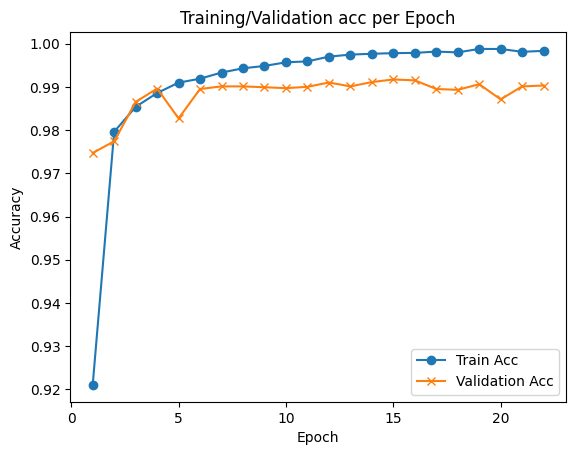

In [39]:
fig, ax = plt.subplots()
ax.plot([None] + history.history['accuracy'], 'o-')
ax.plot([None] + history.history['val_accuracy'], 'x-')
# Plot legend and use the best location automatically: loc = 0.
ax.legend(['Train Acc', 'Validation Acc'], loc = 0)
ax.set_title('Training/Validation acc per Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')

Text(0, 0.5, 'Loss')

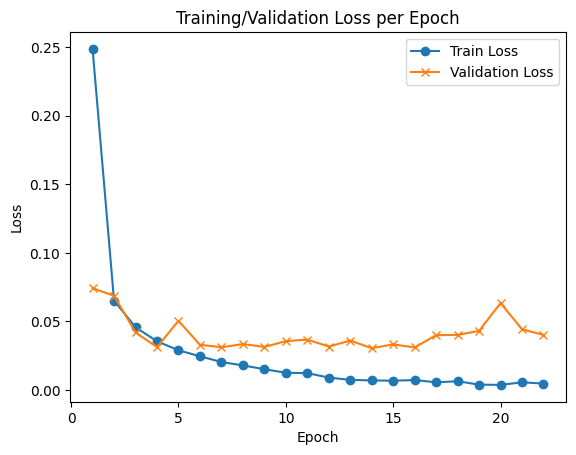

In [40]:
fig, ax = plt.subplots()
ax.plot([None] + history.history['loss'], 'o-')
ax.plot([None] + history.history['val_loss'], 'x-')
# Plot legend and use the best location automatically: loc = 0.
ax.legend(['Train Loss', 'Validation Loss'], loc = 0)
ax.set_title('Training/Validation Loss per Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')

#### Save and load model

In [41]:
model.save('lenet5.keras')

In [42]:
loaded_model = tf.keras.models.load_model("lenet5.keras")

Check the test accuracy of the saved model:

In [43]:
scores = loaded_model.evaluate(X_te, y_te, verbose=0)
print("\n Testing/Validation accuracy of the saved model: %.2f%%" % (scores[1]*100))


 Testing/Validation accuracy of the saved model: 99.17%
